# EDA - ULB credit card fraud (OpenML 1597)

284,807 card transactions over two days, 492 frauds (0.17 %). Features V1..V28 are PCA components (anonymised),
plus `Time` (seconds since the first transaction) and `Amount`. Questions this notebook answers before modelling:

1. How rare is fraud, and does the base rate drift across the two days? (matters for the chronological split)
2. Do fraud amounts look different from legitimate amounts?
3. Is there a time-of-day pattern?
4. Which raw features separate the classes most (candidate top features for the model)?
5. Do the engineered velocity features carry signal?

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fraudpipe.data import load_creditcard
from fraudpipe.features import build_features
df = load_creditcard("../data")
print(df.shape); df["Class"].value_counts().rename("count").to_frame().assign(pct=lambda t: (100*t["count"]/len(df)).round(3))

(284807, 31)


,count,pct
Class,,
0,284315,99.827
1,492,0.173


## 1. Base rate over time (chronological split sanity check)

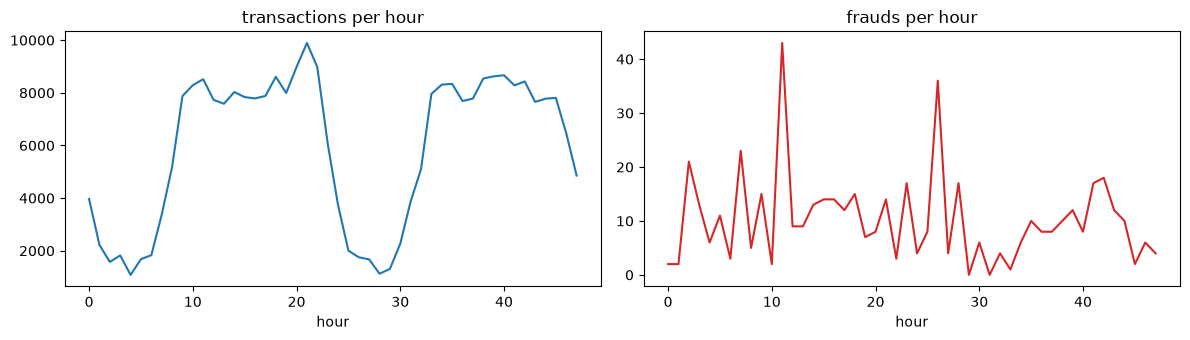

fraud in first 60% / next 20% / last 20%: 360 57 75


In [2]:
df["hour"] = (df["Time"] // 3600).astype(int)
by_hour = df.groupby("hour")["Class"].agg(["size", "sum"]).rename(columns={"size": "txns", "sum": "fraud"})
by_hour["fraud_rate_pct"] = 100 * by_hour["fraud"] / by_hour["txns"]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
by_hour["txns"].plot(ax=ax[0], title="transactions per hour"); by_hour["fraud"].plot(ax=ax[1], title="frauds per hour", color="C3")
plt.tight_layout(); plt.show()
n = len(df); print("fraud in first 60% / next 20% / last 20%:", int(df.Class[: int(.6*n)].sum()), int(df.Class[int(.6*n): int(.8*n)].sum()), int(df.Class[int(.8*n):].sum()))

## 2. Amount by class

In [3]:
desc = df.groupby("Class")["Amount"].describe().round(2); desc

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87


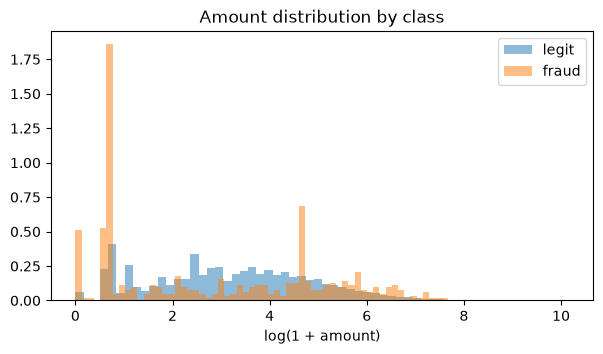

share of fraud with amount == 0: 5.5 %  vs legit: 0.6 %


In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for c, lab in ((0, "legit"), (1, "fraud")):
    ax.hist(np.log1p(df.loc[df.Class == c, "Amount"]), bins=60, density=True, alpha=.5, label=lab)
ax.set_xlabel("log(1 + amount)"); ax.legend(); ax.set_title("Amount distribution by class"); plt.show()
print("share of fraud with amount == 0:", round(100*(df.loc[df.Class==1,'Amount']==0).mean(),1), "%  vs legit:", round(100*(df.loc[df.Class==0,'Amount']==0).mean(),1), "%")

## 3. Time of day

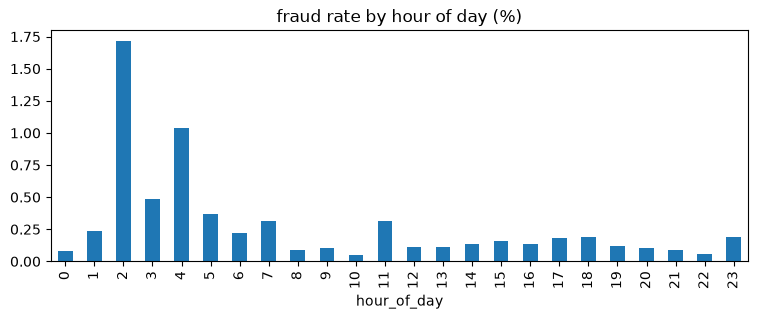

,size,mean,fraud_rate_pct
hour_of_day,,,
2,3328,0.017127,1.712740
4,2209,0.010412,1.041195
3,3492,0.004868,0.486827
5,2990,0.003679,0.367893
7,7243,0.003175,0.317548


In [5]:
df["hour_of_day"] = ((df["Time"] % 86400) // 3600).astype(int)
tod = df.groupby("hour_of_day")["Class"].agg(["size", "mean"]); tod["fraud_rate_pct"] = 100*tod["mean"]
ax = tod["fraud_rate_pct"].plot(kind="bar", figsize=(9, 3), title="fraud rate by hour of day (%)"); plt.show()
tod.sort_values("fraud_rate_pct", ascending=False).head(5)

## 4. Which raw features separate the classes?

In [6]:
v = [f"V{i}" for i in range(1, 29)]
sep = pd.DataFrame({"mean_legit": df.loc[df.Class==0, v].mean(), "mean_fraud": df.loc[df.Class==1, v].mean(), "std": df[v].std()})
sep["standardised_gap"] = ((sep["mean_fraud"] - sep["mean_legit"]) / sep["std"]).abs()
sep.sort_values("standardised_gap", ascending=False).head(10).round(2)

,mean_legit,mean_fraud,std,standardised_gap
V17,0.01,-6.67,0.85,7.86
V14,0.01,-6.97,0.96,7.29
V12,0.01,-6.26,1.00,6.28
V10,0.01,-5.68,1.09,5.22
V16,0.01,-4.14,0.88,4.73
V3,0.01,-7.03,1.52,4.65
V7,0.01,-5.57,1.24,4.51
V11,-0.01,3.80,1.02,3.73
V4,-0.01,4.54,1.42,3.21
V18,0.00,-2.25,0.84,2.68


## 5. Engineered velocity features (global key - no card id in this dataset)

In [7]:
feats = build_features(df.drop(columns=["hour", "hour_of_day"]))
vel = ["vel_1h_count", "vel_24h_count", "vel_1h_amount", "amount_z_24h", "secs_since_prev", "is_night", "amount_is_round"]
feats.groupby("Class")[vel].mean().T.round(3).rename(columns={0: "legit", 1: "fraud"})

/Users/lukefreyman/Desktop/fraud-detection-pipeline/notebooks/../src/fraudpipe/features.py:65: RuntimeWarning: divide by zero encountered in divide
  new_cols["amount_z_24h"][p] = np.where(std > 0, (a - mean) / std, 0.0)


Class,legit,fraud
vel_1h_count,7244.322,6081.165
vel_24h_count,108252.603,95259.183
vel_1h_amount,661371.674,561267.252
amount_z_24h,0.002,0.151
secs_since_prev,4.123,1.087
is_night,0.084,0.252
amount_is_round,0.242,0.299


### Takeaways
* Fraud is 0.17 % of rows - accuracy is meaningless; PR-AUC and recall at a fixed review budget are the metrics.
* The chronological split leaves roughly 100 frauds in the last 20 % - enough to evaluate, small enough that
  results carry sampling noise (see README limitations).
* Several PCA components (V14, V17, V12, V10, V4, V11...) separate the classes by several standard deviations -
  the model's top SHAP features should come from this list.
* The velocity features differ modestly between classes on a global key; on real data with card ids they would be
  per-card and far stronger.